Differential condensability analysis and plots

In [2]:
# python modules
import sys, re, glob
from collections import defaultdict
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
from scipy import stats

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Matplotlib:", mpl.__version__)
print("SciPy:", scipy.__version__)

# custom modules - Customized to BackupHaLab/
# working_dir = '/Volumes/BackupHaLab'
working_dir = '/lab-share/PCMM-Ha-e2/Public/Xin'
sys.path.append(f'{working_dir}/condense-seq/postpro_scripts')
import graphics_edit as graphics
import load_file_edit as load_file
import Interval_dict_python3
import statis_edit as statis

Python: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]
NumPy: 2.2.6
Matplotlib: 3.10.7
SciPy: 1.14.1


ModuleNotFoundError: No module named 'graphics_edit'

In [ ]:
# matplotlib setting
%matplotlib inline
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["savefig.facecolor"] = "white"

: 

In [ ]:
### parameters
cell_org = {'H1':'human',
            'GM':'human',
            'mCD8T:WT':'mouse',
            'mCD8T:DFMO':'mouse',
            'mCD8T:ODCKO':'mouse'}

cell_chrnames = {'H1':['chr%s' % (i) for i in range(1, 23)] + ['chrX', 'chrY'],
                 'GM':['chr%s' % (i) for i in range(1, 23)] + ['chrX'],
                 'mCD8T:WT':['chr%s' % (i) for i in range(1, 20)] + ['chrX'],
                 'mCD8T:DFMO':['chr%s' % (i) for i in range(1, 20)] + ['chrX'],
                 'mCD8T:ODCKO':['chr%s' % (i) for i in range(1, 20)] + ['chrX']}

: 

In [ ]:
def plot_score_scatter (ID_score1,
                        ID_score2,
                        ID_color,
                        IDs=None,
                        standardize_color=True,
                        ID_text={},
                        fig_width=None,
                        fig_height=None,
                        vmin=-5,
                        vmax=5,
                        alpha=0.3,
                        size=2,
                        xlim=[None,None],
                        ylim=[None,None],
                        xlabel='',
                        ylabel='',
                        title=None,
                        cbar_ylabel='',
                        show=True,
                        save_path='./',
                        save=False,
                        note=''):

    # custom diverging colormap with white background
    pastel_jet = mpl.colors.LinearSegmentedColormap.from_list('white_viridis',
                                                   [(0, 'darkblue'),
                                                    (0.1, 'blue'),
                                                    (0.2, 'tab:blue'),
                                                    (0.4, 'tab:cyan'),
                                                    (0.5, 'ivory'),
                                                    (0.6, 'tab:orange'),
                                                    (0.8, 'tab:red'),
                                                    (0.9, 'red'),
                                                    (1, 'darkred')
                                                    ], N=256)

    all_IDs = set(ID_score1.keys()) & set(ID_score2.keys())

    if IDs == None:
        IDs = all_IDs
    else:
        IDs = all_IDs & set(IDs)

    out_IDs = IDs & set(ID_text.keys())
    IDs -= out_IDs

    IDs = sorted(list(IDs))
    out_IDs = sorted(list(out_IDs))
    
    X, Y = [], []
    C = []
    for ID in IDs:
        X.append(ID_score1[ID])
        Y.append(ID_score2[ID])
        C.append(ID_color[ID])

    if standardize_color:
        C = stats.zscore(C)

    # draw all genes
    if fig_width==None or fig_height==None:
        fig = plt.figure()
    else:
        fig = plt.figure(figsize=(fig_width,
                                  fig_height))
    
    plt.scatter(X,
                Y,
                c=C,
                cmap=pastel_jet,
                vmin=vmin,
                vmax=vmax,
                alpha=alpha,
                s=size)

    for ID in out_IDs:
        text = ID_text[ID]
        x, y = ID_score1[ID], ID_score2[ID]
        
        plt.plot(x,
                 y,
                 'kx',
                 markersize=6,
                 alpha=1,
                 zorder=10,
                 mew=2)
        
        plt.annotate(text,
                     (x+0.05, y+0.05),
                     color='black',
                     zorder=40,
                     size=10,
                     weight='bold')

    plt.plot(xlim,
             ylim,
             'k--',
             alpha=0.7)
    
    plt.xlim(xlim)
    plt.ylim(ylim)

    plt.xlabel(xlabel, fontsize=13)
    plt.ylabel(ylabel, fontsize=13)

    if title!=None:
        plt.title(title, fontsize=15)

    cbar = plt.colorbar()
    cbar.ax.set_ylabel(cbar_ylabel,
                       rotation=-90,
                       va="bottom")

    if save:
        #plt.savefig(save_path + "score_scatter_%s.png" % (note),
        #            bbox_inches='tight',
        #            dpi=300)
        plt.savefig(save_path + "score_scatter_%s.svg" % (note),
                    bbox_inches='tight')
    if show:
        plt.tight_layout()
        plt.show()
    plt.close()


: 

In [ ]:
### set target chromosome
chr_choices = cell_chrnames['mCD8T:WT']

: 

In [ ]:
### read GTF file
GTF_path = working_dir + '/condense-seq/data/MouseEpigeneticData/GTF/'
GTF_fname = 'ENCFF871VGR.gtf'
geneID_field_value = load_file.read_GTF (GTF_path + GTF_fname,
                                         chr_list=chr_choices)

: 

In [ ]:
### get near TSS interval for each genes
chr_geneID_interval = {}
for geneID in geneID_field_value:
    try:
        chr = geneID_field_value[geneID]['chr']
        pos = geneID_field_value[geneID]['TSS']
    except:
        continue
    interval = (pos-2500, pos+2500)

    if chr not in chr_geneID_interval:
        chr_geneID_interval[chr] = {}
    chr_geneID_interval[chr][geneID] = interval

print('Total gene count:', len(geneID_field_value)) #DEBUG: as long as the number is not 0, it means the GTF file is read successfully

Total gene count: 80062


: 

In [ ]:
### load bedgraph files
bdg_dir = working_dir + "/analysis_v2/bigwig/"

dinfo_key = {
    'E14_NCP_titr11_2rep_binsize25000_smoothed.bdg' : (2, 'E14', 'NCP', 'sp', 11),
    'E14_NCP_titr15_2rep_binsize25000_smoothed.bdg' : (2, 'E14', 'NCP', 'sp', 15),
    'Exp1-Samp11_S2_binsize25000_smoothed.bdg': (1, 'E14', 'Exp1', 'sp', 11),
    'Exp1-Samp15_S3_binsize25000_smoothed.bdg': (1, 'E14', 'Exp1', 'sp', 15),
    'Exp2-Samp11_S5_binsize25000_smoothed.bdg': (1, 'E14', 'Exp2', 'sp', 11),
    'Exp2-Samp15_S6_binsize25000_smoothed.bdg': (1, 'E14', 'Exp2', 'sp', 15),
    'Exp3-Samp11_S8_binsize25000_smoothed.bdg': (1, 'E14', 'Exp3', 'sp', 11),
    'Exp3-Samp15_S9_binsize25000_smoothed.bdg': (1, 'E14', 'Exp3', 'sp', 15),
    'Exp4-Samp11_S11_binsize25000_smoothed.bdg': (1, '2i', 'Exp4', 'sp', 11),
    'Exp4-Samp15_S12_binsize25000_smoothed.bdg': (1, '2i', 'Exp4', 'sp', 15),
    'Exp5-Samp11_S14_binsize25000_smoothed.bdg': (1, '2i', 'Exp5', 'sp', 11),
    'Exp5-Samp15_S15_binsize25000_smoothed.bdg': (1, '2i', 'Exp5', 'sp', 15),
    'Exp6-Samp11_S17_binsize25000_smoothed.bdg': (1, '2i', 'Exp6', 'sp', 11),
    'Exp6-Samp15_S18_binsize25000_smoothed.bdg': (1, '2i', 'Exp6', 'sp', 15),
}

: 

In [ ]:
### custom bin_data_mean function to work around statis_edit.py bug
def custom_bin_data_mean(binID_interval, ID_loc, ID_value, min_sample_size=10, skip_nan=True):
    """
    Custom implementation of bin_data_mean without the double_hash subscript bug.
    
    Parameters:
    - binID_interval: dict {binID: (start, end)}
    - ID_loc: dict {ID: position}
    - ID_value: dict {ID: value}
    - min_sample_size: minimum samples required per bin
    - skip_nan: whether to skip NaN values
    """
    binID_mscore = {}
    
    for binID, (start, end) in binID_interval.items():
        values = []
        
        # Find all values that fall within this interval
        for idx, pos in ID_loc.items():
            if start <= pos <= end:
                val = ID_value[idx]
                
                # Skip NaN if requested
                if skip_nan and (isinstance(val, float) and np.isnan(val)):
                    continue
                
                values.append(val)
        
        # Only store if we have enough samples
        if len(values) >= min_sample_size:
            binID_mscore[binID] = np.mean(values)
    
    return binID_mscore

: 

In [ ]:
### load condense-seq data and get mean score near TSS of genes
dkey_geneID_mscore = {}
for fkey in dinfo_key:
    field_dkey = dinfo_key[fkey]

    for fname in glob.glob(bdg_dir + '*'):
        if not re.match(fkey, fname.rsplit('/')[-1]):
            continue

        print("loading %s" % (fname.rsplit('/')[-1]))

        field_chr_ID_value = load_file.read_bedgraph(fname,
                                                 chr_choices=chr_choices,
                                                 skip_nan=True,
                                                 by_chr=True)
        
        for chr, ID_value in field_chr_ID_value.items():
            geneID_interval = chr_geneID_interval[chr]

            # Build ID_loc and ID_value_dict
            ID_loc = {}
            ID_value_dict = {}
            
            for idx, ID_key in enumerate(ID_value.keys()):
                score = ID_value[ID_key]
                start_pos = ID_key[1]
                ID_loc[idx] = start_pos
                ID_value_dict[idx] = score

            # CALL CUSTOM FUNCTION HERE (instead of statis.bin_data_mean)
            geneID_mscore = custom_bin_data_mean(geneID_interval,
                                                ID_loc,
                                                ID_value_dict,
                                                min_sample_size=1,
                                                skip_nan=True)
            
            if field_dkey not in dkey_geneID_mscore:
                dkey_geneID_mscore[field_dkey] = {}
            dkey_geneID_mscore[field_dkey].update(geneID_mscore)
    
    # QC sanity check - DEBUG
    if len(dkey_geneID_mscore[field_dkey]) !=0 :
        print(f"{len(dkey_geneID_mscore[field_dkey])} condensability score is found in {(fname.rsplit('/')[-1])}")
    else:
        raise ValueError("The input was NOT read in any condensability score...")

loading E14_NCP_titr11_2rep_binsize25000_smoothed.bdg
10873 condensability score is found in Exp6-Samp15_S18_binsize25000_smoothed.bw
loading E14_NCP_titr15_2rep_binsize25000_smoothed.bdg
10873 condensability score is found in Exp6-Samp15_S18_binsize25000_smoothed.bw
loading Exp1-Samp11_S2_binsize25000_smoothed.bdg
10874 condensability score is found in Exp6-Samp15_S18_binsize25000_smoothed.bw
loading Exp1-Samp15_S3_binsize25000_smoothed.bdg
10874 condensability score is found in Exp6-Samp15_S18_binsize25000_smoothed.bw
loading Exp2-Samp11_S5_binsize25000_smoothed.bdg
10873 condensability score is found in Exp6-Samp15_S18_binsize25000_smoothed.bw
loading Exp2-Samp15_S6_binsize25000_smoothed.bdg
10873 condensability score is found in Exp6-Samp15_S18_binsize25000_smoothed.bw
loading Exp3-Samp11_S8_binsize25000_smoothed.bdg
10874 condensability score is found in Exp6-Samp15_S18_binsize25000_smoothed.bw
loading Exp3-Samp15_S9_binsize25000_smoothed.bdg
10874 condensability score is found in

: 

This is an issue in loading the bedgraphs in. There is a pre-existing parameter that is looking for potential amount of repeats in the dataset. However, since I re-construct the variables, now the loading of samples are not happening at once. They are loaded individually.

*It makes since to do a sample-size control. However, I need to find the balanced way.*

In [ ]:
### read RNA-seq data
RNAseq_path = working_dir + '/condense-seq/data/MouseEpigeneticData/'
cell_RNAseq_fname = {'E14':'E14_RNAseq/ENCFF827OZU.tsv',
                     '2i':'2i_RNAseq/quant/GSM3426952.genes.results',
                    }
dkey_geneID_FPKM = {}
for dkey in dkey_geneID_mscore:
    cell = dkey[1]
    #exten, dtype, resol, rep, cell, sample, agent, tnum = dkey
    RNAseq_fname = cell_RNAseq_fname[cell]
    geneID_FPKM = load_file.read_ENCODE_RNA_seq(RNAseq_path + RNAseq_fname)
    dkey_geneID_FPKM[dkey] = geneID_FPKM

print(len(dkey_geneID_FPKM[(1, '2i', 'Exp4', 'sp', 15)]))

55563


: 

In [ ]:
### define common geneIDs
target_geneIDs = set([])

for index, (dkey, geneID_mscore) in enumerate(dkey_geneID_mscore.items()):
    geneID_mscore = dkey_geneID_mscore[dkey]
    geneIDs = set(geneID_mscore.keys())

    if index == 0:
        target_geneIDs |= geneIDs
        continue
    target_geneIDs &= geneIDs
target_geneIDs = sorted(list(target_geneIDs))

print('Total gene count:', len(target_geneIDs)) # DEBUG

Total gene count: 10872


: 

In [ ]:
### standardize the condensability scores
dkey_geneID_zscore = {}
for dkey in dkey_geneID_mscore.keys():
    geneID_mscore = dkey_geneID_mscore[dkey]
    geneID_zscore = statis.standardize_dict(geneID_mscore,
                                            keys=target_geneIDs)
    dkey_geneID_zscore[dkey] = geneID_zscore    

: 

In [ ]:
### get gene expression differences
dkey1 = (2, 'E14', 'NCP', 'sp', 11)
dkey2 = (1, '2i', 'Exp4', 'sp', 11)
geneID_dlogFPKM = {}
for geneID in target_geneIDs:
    try:
        FPKM1 = dkey_geneID_FPKM[dkey1][geneID]
        FPKM2 = dkey_geneID_FPKM[dkey2][geneID]
    except:
        continue
    dlogFPKM = np.log2(1+FPKM2) - np.log2(1+FPKM1)
    geneID_dlogFPKM[geneID] = dlogFPKM

print(f"The length of geneID_dlogFPKM is {len(geneID_dlogFPKM.keys())}")

The length of geneID_dlogFPKM is 10821


: 

In [ ]:
### set stem cell marker genes
ESC_tf_cores_mouse = ['Pou5f1', 'Sox2', 'Klf4', 'Nanog']
ESC_tf_others_mouse = [
'Zfp42',
'Utf1',
'Zfx',
'Tbx3',
'Foxd3',
'Hmga2',
'Nacc1',
'Nr6a1',
'Stat3',
'Lef1',
'Tcf3',
'Sall4',
'Fbxo15',
'L1td1',
'Gdf3',
'Dppa5a',
'Dppa4',
'Dppa2',
'Dppa3'
]
# ESC_tf_cores = [gname.upper() for gname in ESC_tf_cores_mouse]
# ESC_tf_others = [gname.upper() for gname in ESC_tf_others_mouse]
ESC_gnames = ESC_tf_cores_mouse + ESC_tf_others_mouse

: 

I've removed the .upper() of all the gene names, becuase I think mouse gene names are suppose to have lower cases. It's kind of common to use lower cases in mouse gene if it's an orthologs to a human gene. 

In [ ]:
### find Ensemble Gene ID for stem cell marker genes
ESC_gname_geneIDs = {gname :[] for gname in ESC_gnames}
for geneID in target_geneIDs:
    gname = geneID_field_value[geneID]['geneName']
    try:
        ESC_gname_geneIDs[gname].append(geneID)
    except:
        continue

ESC_geneID_gname = {}
for gname in ESC_gname_geneIDs:
    if len(ESC_gname_geneIDs[gname]) == 1:
        geneID = ESC_gname_geneIDs[gname][0]
        assert geneID not in ESC_geneID_gname
        ESC_geneID_gname[geneID] = gname

geneID_text = {}
# for geneID in ESC_geneID_gname:
#     gname = ESC_geneID_gname[geneID]
#     if gname in ESC_tf_cores:
#         text = gname
#     else:
#         text = ''
#         #text = gname
#     geneID_text[geneID] = text


: 

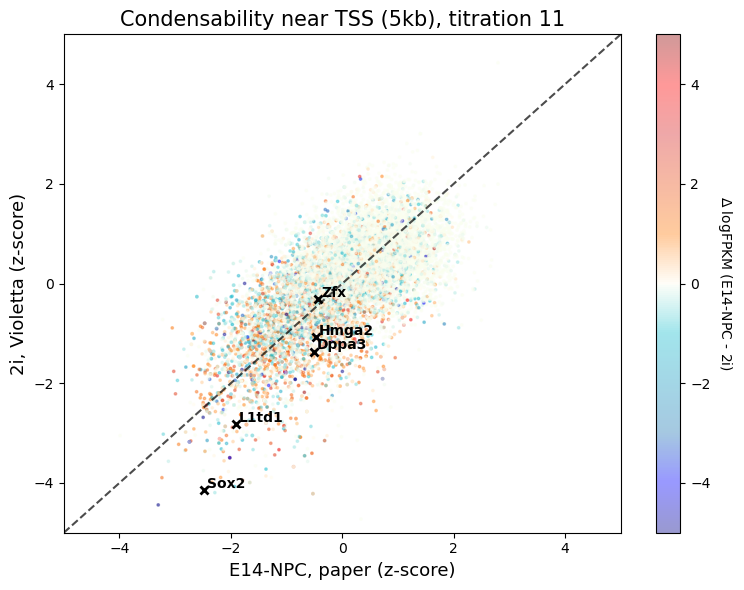

: 

In [ ]:
### plot condensability with gene expression differences [Fig.1f]
geneID_zscorex = dkey_geneID_zscore[dkey1]
geneID_zscorey = dkey_geneID_zscore[dkey2]

zscorex_label = 'E14-NPC, paper (z-score)'
zscorey_label = '2i, Violetta (z-score)'
# Selecting target_geneIDs that exists among all inputs
target_geneIDs = (
    set(target_geneIDs)
    & set(geneID_zscorex)
    & set(geneID_zscorey)
    & set(geneID_dlogFPKM)
)
# Define limit for plotting
lim = 5

# Execute the plotting function...
plot_score_scatter (geneID_zscorex,
                    geneID_zscorey,
                    geneID_dlogFPKM,
                    IDs=target_geneIDs,
                    standardize_color=True,
                    ID_text=ESC_geneID_gname,
                    fig_width=7.8,
                    fig_height=6,
                    vmin=-5,
                    vmax=5,
                    alpha=0.4,
                    size=3,
                    xlim=[-1*lim,lim],
                    ylim=[-1*lim,lim],
                    xlabel=zscorex_label,
                    ylabel=zscorey_label,
                    title='Condensability near TSS (5kb), titration 11',
                    cbar_ylabel='$\\Delta$ logFPKM (E14-NPC - 2i)',
                    save_path=f"{working_dir}/analysis_v2/condensability_vs_TSS/",
                    save=True,
                    note='E14vs2i_titr11')


In [ ]:
# Generate a table for manual screening
import pandas as pd

# 1. Build the "values" dataframe
common_genes = set(geneID_zscorex) & set(geneID_zscorey) & set(geneID_dlogFPKM)

df_vals = pd.DataFrame({
    'geneID': list(common_genes),
    zscorex_label: [geneID_zscorex[g] for g in common_genes],
    zscorey_label: [geneID_zscorey[g] for g in common_genes],
    'dlogFPKM': [geneID_dlogFPKM[g] for g in common_genes]
})

# 2. Convert "geneID_field_value" into a dataframe
df_annot = (
    pd.DataFrame.from_dict(geneID_field_value, orient="index")
      .reset_index()
      .rename(columns={"index": "geneID"})
)

# 3. Merge on "geneID"
df = df_vals.merge(df_annot, on="geneID", how="left")
df["geneName"] = df["geneName"].fillna(df["geneID"])

# 4. Sort and write TSV
desired_cols = [
    "geneName",
    zscorex_label,
    zscorey_label,
    "dlogFPKM",
    "chr",
    "TSS",
    "TTS",
    "strand",
    "geneID",
    "geneType"
]
df = df[[c for c in desired_cols if c in df.columns]]

df_sorted = df.sort_values(
    by = [zscorex_label, zscorey_label, 'dlogFPKM'],
    ascending = [True, True, True]
).reset_index(drop=True)

df_sorted.to_csv(
    f"{working_dir}/analysis_v2/condensability_vs_TSS/{zscorex_label}_vs_{zscorey_label}.condensabilityNearTSS.titr11.tsv",
    sep = "\t",
    index = False
)

print(df_sorted.head()) #DEBUG

   geneName  E14-NPC, paper (z-score)  2i, Violetta (z-score)  dlogFPKM  \
0   Gm45564                 -3.989611               -3.050026 -0.007905   
1   Gm37376                 -3.304135               -4.441787 -4.496335   
2   Gm27694                 -3.304135               -4.441787  0.000000   
3    Prrc2b                 -3.237829               -3.895063  1.091537   
4  Mir3473c                 -3.223295               -0.720959  0.000000   

     chr          TSS          TTS strand              geneID        geneType  
0   chr7   45551614.0   45550533.0      -  ENSMUSG00000110144       antisense  
1  chr19    5801940.0    5802392.0      +  ENSMUSG00000102349             TEC  
2  chr19    5799084.0    5798999.0      -  ENSMUSG00000098462        misc_RNA  
3   chr2   32151081.0   32234536.0      +  ENSMUSG00000039262  protein_coding  
4   chr1  191998633.0  191998553.0      -  ENSMUSG00000093003           miRNA  


: 

In [1]:
import pandas as pd

df.head()


NameError: name 'df' is not defined